# Exploratory Data Analysis (EDA) & Data Audit

---
## 0. Library & Configuration

In [94]:
import hashlib
import re
from itertools import combinations
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from tqdm import tqdm

# Paths (relative to this notebook)
BASE_DIR = Path.cwd().parent
RAW_DIR = BASE_DIR / "data" / "raw"
REPORTS_DIR = BASE_DIR / "outputs" / "eda"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = REPORTS_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)
CONFIG = yaml.safe_load(
    (BASE_DIR / "configs" / "datasets.yaml").read_text(encoding="utf-8")
)

# Datasets in scope: folder name -> short name
DATASETS = {
    d["name"]: re.sub(r"\.v\d+i\.yolo\d+$", "", d["name"])
    for d in CONFIG["direct_datasets"] + CONFIG["roboflow_datasets"]
}

SEED = 42  # image sampling (Section 4)
IMGSZ = 640  # training input size (Section 8)
NEAR_DUP_BITS = (
    12  # max differing dHash bits for near-duplicate candidates (Section 11)
)
LAYOUT_IOU = 0.5  # near-duplicates also need the same box layout (Section 11)
SPLIT_RATIO = (8, 1, 1)  # train:val:test ratio for the split simulation (Section 13)
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}
SPLITS = ["train", "val", "test"]
SPLIT_ALIAS = {"valid": "val"}
TOL = 1e-3  # tolerance for normalized coordinates (Section 3)
DUP_IOU = 0.9  # IoU above this = duplicate annotation (Section 3)

print(f"Base Directory : {BASE_DIR}")
print(f"Raw Datasets   : {RAW_DIR}")
print(f"Reports        : {REPORTS_DIR}")
print(f"Datasets       : {list(DATASETS.values())}")

Base Directory : d:\project\pilltally\ml
Raw Datasets   : d:\project\pilltally\ml\data\raw
Reports        : d:\project\pilltally\ml\outputs\eda
Datasets       : ['medical-pills', 'CountingPills', 'Pill Detection']


---
## 1. Dataset Index

All files are scanned **once** into two tables.

**`df_img`** — one row per image

| Column | Description |
| ------ | ----------- |
| `dataset` | Dataset name |
| `split` | train / val / test |
| `file` | File name |
| `path` | Image path |
| `ext` | File extension |
| `size` | (width, height) in pixels |
| `n_object` | Number of labeled objects |
| `n_overlap` | Number of touching box pairs |
| `md5` | File hash → exact duplicates |
| `dhash` | Perceptual hash → near-duplicates |

**`df_ann`** — one row per object, linked to `df_img` by `path`

| Column | Description |
| ------ | ----------- |
| `dataset`, `split`, `path` | Image containing the object |
| `orig_class` | Original class ID |
| `fmt` | `bbox` / `polygon` |
| `cx`, `cy` | Box center (normalized 0–1) |
| `w`, `h` | Box width & height (normalized 0–1) |

### 1.1 Helper Functions

Two folder layouts:

| Source | Image | Label |
| ------ | ----- | ----- |
| Roboflow | `train/images/x.jpg` | `train/labels/x.txt` |
| Ultralytics | `images/train/x.jpg` | `labels/train/x.txt` |

A YOLO label line is a bbox `class cx cy w h` or a polygon `class x1 y1 x2 y2 ...`. Polygons are converted to their min–max bounding box.

In [95]:
def split_of(rel_parts):
    # Roboflow: ("train", "images", "x.jpg"); Ultralytics: ("images", "train", "x.jpg")
    split = rel_parts[1] if rel_parts[0] in ("images", "labels") else rel_parts[0]
    return SPLIT_ALIAS.get(split, split)  # "valid" -> "val"


def label_of(img_path):
    # .../images/x.jpg -> .../labels/x.txt
    parts = []
    for part in img_path.parts:
        if part == "images":
            parts.append("labels")
        else:
            parts.append(part)
    return Path(*parts).with_suffix(".txt")


def read_label(label_path):
    """Parse a YOLO label file into a list of {orig_class, fmt, cx, cy, w, h}."""
    objects = []
    if not label_path.exists():
        return objects
    for line in label_path.read_text(encoding="utf-8").splitlines():
        values = line.split()
        if not values:
            continue
        cls = int(values[0])
        coords = [float(v) for v in values[1:]]
        if len(coords) == 4:
            fmt = "bbox"
            cx, cy, w, h = coords
        elif len(coords) >= 6 and len(coords) % 2 == 0:
            fmt = "polygon"
            xs = coords[0::2]
            ys = coords[1::2]
            w = max(xs) - min(xs)
            h = max(ys) - min(ys)
            cx = min(xs) + w / 2
            cy = min(ys) + h / 2
        else:
            continue  # invalid column count
        objects.append(
            {"orig_class": cls, "fmt": fmt, "cx": cx, "cy": cy, "w": w, "h": h}
        )
    return objects


def touching(a, b):
    """True if two boxes intersect (positive overlap width and height)."""
    overlap_w = min(a["cx"] + a["w"] / 2, b["cx"] + b["w"] / 2) - max(
        a["cx"] - a["w"] / 2, b["cx"] - b["w"] / 2
    )
    overlap_h = min(a["cy"] + a["h"] / 2, b["cy"] + b["h"] / 2) - max(
        a["cy"] - a["h"] / 2, b["cy"] - b["h"] / 2
    )
    return overlap_w > 0 and overlap_h > 0


def count_overlap(objects):
    """Number of touching box pairs, each pair counted once."""
    count = 0
    for a, b in combinations(objects, 2):
        if touching(a, b):
            count += 1
    return count


def dhash(gray, size=16):
    """256-bit difference hash as a 64-character hex string."""
    small = cv2.resize(gray, (size + 1, size), interpolation=cv2.INTER_AREA)
    bits = small[:, 1:] > small[:, :-1]  # each pixel vs. its left neighbor
    return np.packbits(bits).tobytes().hex()

### 1.2 Scan All Images

In [96]:
img_rows = []
ann_rows = []
for folder, ds in DATASETS.items():
    ds_dir = RAW_DIR / folder

    images = []
    for p in ds_dir.rglob("*"):
        if p.suffix.lower() in IMAGE_EXTS:
            images.append(p)
    images.sort()

    for path in tqdm(images, desc=ds):
        split = split_of(path.relative_to(ds_dir).parts)
        raw = path.read_bytes()  # read once: used for md5 and decoding
        gray = cv2.imdecode(np.frombuffer(raw, np.uint8), cv2.IMREAD_GRAYSCALE)
        height, width = gray.shape
        objects = read_label(label_of(path))

        img_rows.append(
            {
                "dataset": ds,
                "split": split,
                "file": path.name,
                "path": path,
                "ext": path.suffix.lower(),
                "size": (width, height),
                "n_object": len(objects),
                "n_overlap": count_overlap(objects),
                "md5": hashlib.md5(raw).hexdigest(),
                "dhash": dhash(gray),
            }
        )
        for obj in objects:
            row = {"dataset": ds, "split": split, "path": path}
            row.update(obj)  # orig_class, fmt, cx, cy, w, h
            ann_rows.append(row)

df_img = pd.DataFrame(img_rows)
df_ann = pd.DataFrame(ann_rows)
for df in (df_img, df_ann):
    df["split"] = pd.Categorical(df["split"], SPLITS)  # train -> val -> test order

Pill Detection: 100%|██████████| 1489/1489 [00:12<00:00, 114.59it/s]


### 1.3 Export

`df_img` and `df_ann` are saved for the next pipeline steps. Paths are relative to `ml/`.

In [97]:
def rel(p):
    return p.relative_to(BASE_DIR).as_posix()


df_img.assign(path=df_img["path"].map(rel)).to_parquet(
    REPORTS_DIR / "image_index.parquet", index=False
)
df_ann.assign(path=df_ann["path"].map(rel)).to_parquet(
    REPORTS_DIR / "annotation_index.parquet", index=False
)
print(f"image_index.parquet      : {len(df_img):,} rows")
print(f"annotation_index.parquet : {len(df_ann):,} rows")

image_index.parquet      : 8,615 rows
annotation_index.parquet : 33,319 rows


---
## 2. Dataset Overview

### 2.1 Dataset Inventory

Read from `data.yaml` / `<name>.yaml` and `README.roboflow.txt`. **Annotation** = formats found in `df_ann`.

In [98]:
def dataset_yaml(ds_dir):
    # Roboflow uses "data.yaml", Ultralytics "<folder>.yaml"
    for path in [ds_dir / "data.yaml", ds_dir / f"{ds_dir.name}.yaml"]:
        if path.exists():
            return yaml.safe_load(path.read_text(encoding="utf-8"))
    raise FileNotFoundError(f"No dataset yaml in {ds_dir}")


def readme_bullets(text, start, end=None):
    """Join the '* ...' lines that follow `start` (and precede `end`) in a Roboflow README."""
    if start not in text:
        return "-"
    part = text.split(start, 1)[1]
    if end is not None and end in part:
        part = part.split(end, 1)[0]
    bullets = []
    for line in part.splitlines():
        if line.startswith("* "):
            bullets.append(line[2:])
    if not bullets:
        return "-"
    return "; ".join(bullets)


inventory = []
for folder, ds in DATASETS.items():
    ds_dir = RAW_DIR / folder
    meta = dataset_yaml(ds_dir)
    roboflow = meta.get("roboflow", {})  # Roboflow datasets only

    readme = ds_dir / "README.roboflow.txt"
    text = readme.read_text(encoding="utf-8") if readme.exists() else ""
    preprocessing = readme_bullets(
        text, "pre-processing was applied", "augmentation was applied"
    )
    augmentation = readme_bullets(text, "augmentation was applied")
    copies = re.search(
        r"create (\d+) versions", text
    )  # e.g. "create 3 versions of each source image"
    if copies:
        augmentation = f"{copies.group(1)} versions: {augmentation}"

    d = df_img[df_img["dataset"] == ds]
    n = d["split"].value_counts()
    formats = sorted(df_ann.loc[df_ann["dataset"] == ds, "fmt"].unique())

    inventory.append(
        {
            "Dataset": ds,
            "Source": "Roboflow" if roboflow else "Ultralytics",
            "Version": roboflow.get("version", "-"),
            "Preprocessing": preprocessing,
            "Augmentation": augmentation,
            "Train": n["train"],
            "Val": n["val"],
            "Test": n["test"],
            "Total Images": len(d),
            "Orig. Classes": len(meta["names"]),
            "Annotation": " + ".join(formats),
        }
    )

inventory = pd.DataFrame(inventory).set_index("Dataset")
display(inventory)

,Source,Version,Preprocessing,Augmentation,Train,Val,Test,Total Images,Orig. Classes,Annotation
Dataset,,,,,,,,,,
medical-pills,Ultralytics,-,-,-,92,23,0,115,1,bbox
CountingPills,Roboflow,36,Auto-orientation of pixel data (with EXIF-orientation stripping); Resize to 640x640 (S...,3 versions: 50% probability of horizontal flip; Equal probability of one of the follow...,6450,386,175,7011,1,bbox + polygon
Pill Detection,Roboflow,22,-,-,1489,0,0,1489,74,bbox


### 2.2 Folder Structure & File Inventory

**Images** from `df_img`; **Labels** counted from files in `labels` folders.

In [99]:
def print_tree(path, prefix=""):
    # Print subfolders recursively with their file counts
    dirs = sorted(p for p in path.iterdir() if p.is_dir())
    for i, d in enumerate(dirs):
        is_last = i == len(dirs) - 1
        n_files = sum(1 for f in d.iterdir() if f.is_file())
        branch = "└── " if is_last else "├── "
        info = f"  [{n_files} files]" if n_files else ""
        print(prefix + branch + d.name + "/" + info)
        print_tree(d, prefix + ("    " if is_last else "│   "))


for folder in DATASETS:
    print(f"{folder}/")
    print_tree(RAW_DIR / folder)
    print()

# All files under "labels" folders (reused in Section 3)
label_rows = []
for folder, ds in DATASETS.items():
    ds_dir = RAW_DIR / folder
    for p in ds_dir.rglob("*"):
        rel_parts = p.relative_to(ds_dir).parts
        if p.is_file() and "labels" in rel_parts:
            label_rows.append(
                {
                    "dataset": ds,
                    "split": split_of(rel_parts),
                    "path": p,
                    "ext": p.suffix.lower(),
                }
            )
label_files = pd.DataFrame(label_rows)
label_files["split"] = pd.Categorical(label_files["split"], SPLITS)


def join_unique(values):
    # [".jpg", ".png", ".jpg"] -> ".jpg/.png"
    return "/".join(sorted(values.unique()))


keys = ["dataset", "split"]
images = df_img.groupby(keys, observed=True).agg(
    Images=("file", "size"), Image_Ext=("ext", join_unique)
)
labels = label_files.groupby(keys, observed=True).agg(
    Labels=("ext", "size"), Label_Ext=("ext", join_unique)
)

file_inventory = images.join(labels)
file_inventory = file_inventory[["Images", "Labels", "Image_Ext", "Label_Ext"]]
file_inventory.columns = ["Images", "Labels", "Image Extensions", "Label Extensions"]
display(file_inventory)

medical-pills/
├── images/
│   ├── train/  [92 files]
│   └── val/  [23 files]
└── labels/
    ├── train/  [92 files]
    └── val/  [23 files]

CountingPills.v36i.yolo26/
├── test/
│   ├── images/  [175 files]
│   └── labels/  [175 files]
├── train/
│   ├── images/  [6450 files]
│   └── labels/  [6450 files]
└── valid/
    ├── images/  [386 files]
    └── labels/  [386 files]

Pill Detection.v22i.yolo26/
└── train/
    ├── images/  [1489 files]
    └── labels/  [1489 files]



Images  Labels Image Extensions Label Extensions
dataset        split                                                  
CountingPills  train    6450    6450             .jpg             .txt
               val       386     386             .jpg             .txt
               test      175     175             .jpg             .txt
Pill Detection train    1489    1489             .jpg             .txt
medical-pills  train      92      92             .jpg             .txt
               val        23      23             .jpg             .txt

---
## 3. Label Audit

### 3.1 File Integrity

* **Missing label**: image without a label file.
* **Orphan label**: label file without an image.
* **Empty label**: label file with `n_object = 0` (background image) — not an error, checked in Section 4.
* **Duplicate filename**: same file name within or across datasets — matters for naming when merging.

In [100]:
image_labels = df_img["path"].map(label_of)  # label file each image should have
existing_labels = set(label_files["path"])  # label files that exist (from 2.2)

check = df_img[keys].copy()
check["missing"] = ~image_labels.isin(existing_labels)
check["empty"] = ~check["missing"] & (df_img["n_object"] == 0)
check["dup_name"] = df_img["file"].duplicated(keep=False)

# Orphans: label files not owned by any image
orphans = label_files[~label_files["path"].isin(set(image_labels))]

integrity = check.groupby(keys, observed=True).agg(
    Images=("missing", "size"),
    Missing=("missing", "sum"),
    Empty=("empty", "sum"),
    Duplicate=("dup_name", "sum"),
)
integrity["Labels"] = label_files.groupby(keys, observed=True).size()
integrity["Orphan"] = orphans.groupby(keys, observed=True).size()
integrity = integrity.fillna(0).astype(int)  # no labels/orphans -> 0

integrity = integrity[["Images", "Labels", "Missing", "Orphan", "Empty", "Duplicate"]]
integrity.columns = [
    "Images",
    "Labels",
    "Missing Labels",
    "Orphan Labels",
    "Empty Labels",
    "Duplicate Filenames",
]

display(integrity)

Images  Labels  Missing Labels  Orphan Labels  \
dataset        split                                                  
CountingPills  train    6450    6450               0              0   
               val       386     386               0              0   
               test      175     175               0              0   
Pill Detection train    1489    1489               0              0   
medical-pills  train      92      92               0              0   
               val        23      23               0              0   

                      Empty Labels  Duplicate Filenames  
dataset        split                                     
CountingPills  train           990                    0  
               val              40                    0  
               test             19                    0  
Pill Detection train             0                    0  
medical-pills  train             0                    0  
               val               0                    0

### 3.2 Annotation Format & Validity

Per-object checks on `df_ann`:

* Class ID not in `names`
* Width or height ≤ 0
* Box outside the image (tolerance `TOL`)
* Duplicate annotation: IoU > `DUP_IOU` with another object in the same image (the second one is flagged)

Lines with an invalid column count are already skipped by `read_label` (Section 1).

**Mixed Files** contain both bbox and polygon lines. Ultralytics would read the bbox lines as 2-point polygons, so they must be converted explicitly in preprocessing.

In [101]:
def iou(a, b):
    """IoU of two (cx, cy, w, h) boxes. Reused in Section 11."""
    ax, ay, aw, ah = a
    bx, by, bw, bh = b
    inter_w = max(0, min(ax + aw / 2, bx + bw / 2) - max(ax - aw / 2, bx - bw / 2))
    inter_h = max(0, min(ay + ah / 2, by + bh / 2) - max(ay - ah / 2, by - bh / 2))
    inter = inter_w * inter_h
    return inter / (aw * ah + bw * bh - inter + 1e-12)


# Original class count per dataset (from yaml, see 2.1)
n_classes = {}
for folder, ds in DATASETS.items():
    n_classes[ds] = len(dataset_yaml(RAW_DIR / folder)["names"])

left = df_ann["cx"] - df_ann["w"] / 2
right = df_ann["cx"] + df_ann["w"] / 2
top = df_ann["cy"] - df_ann["h"] / 2
bottom = df_ann["cy"] + df_ann["h"] / 2

ann = df_ann[keys].copy()
ann["bbox"] = df_ann["fmt"] == "bbox"
ann["polygon"] = df_ann["fmt"] == "polygon"
ann["bad_class"] = (df_ann["orig_class"] < 0) | (
    df_ann["orig_class"] >= df_ann["dataset"].map(n_classes)
)
ann["bad_size"] = (df_ann["w"] <= 0) | (df_ann["h"] <= 0)
ann["outside"] = (left < -TOL) | (top < -TOL) | (right > 1 + TOL) | (bottom > 1 + TOL)

# Duplicate annotations: compare every object pair within an image
ann["duplicate"] = False
for _, g in df_ann.groupby("path"):
    boxes = list(g[["cx", "cy", "w", "h"]].itertuples(index=False))
    for i, j in combinations(range(len(g)), 2):
        if iou(boxes[i], boxes[j]) > DUP_IOU:
            ann.loc[g.index[j], "duplicate"] = True

ann["invalid"] = ann["bad_class"] | ann["bad_size"] | ann["outside"] | ann["duplicate"]

# Mixed file: bbox and polygon in the same image
n_formats = df_ann.groupby("path")["fmt"].nunique()
mixed_paths = set(n_formats[n_formats > 1].index)
is_mixed = df_img["path"].isin(mixed_paths)

validity = ann.groupby(keys, observed=True).agg(
    Objects=("bbox", "size"),
    BBox=("bbox", "sum"),
    Polygon=("polygon", "sum"),
    Invalid=("invalid", "sum"),
)
validity["Mixed"] = is_mixed.groupby(
    [df_img["dataset"], df_img["split"]], observed=True
).sum()
validity["Invalid %"] = (100 * validity["Invalid"] / validity["Objects"]).round(3)

validity = validity[["Objects", "BBox", "Polygon", "Mixed", "Invalid", "Invalid %"]]
validity.columns = [
    "Objects",
    "BBox",
    "Polygon",
    "Mixed Files",
    "Invalid Rows",
    "Invalid %",
]
display(validity)

# Invalid row examples (if any)
invalid_rows = df_ann[ann["invalid"]].join(
    ann[["bad_class", "bad_size", "outside", "duplicate"]]
)
if invalid_rows.empty:
    print("No invalid annotation rows.")
else:
    display(invalid_rows.head(10))

Objects  BBox  Polygon  Mixed Files  Invalid Rows  \
dataset        split                                                      
CountingPills  train    22779    30    22749            6             0   
               val       2014   685     1329            9             0   
               test       842   500      342            0             0   
Pill Detection train     5662  5662        0            0             0   
medical-pills  train     1623  1623        0            0             0   
               val        399   399        0            0             0   

                      Invalid %  
dataset        split             
CountingPills  train        0.0  
               val          0.0  
               test         0.0  
Pill Detection train        0.0  
medical-pills  train        0.0  
               val          0.0

No invalid annotation rows.


---
## 4. Annotation Completeness Audit

For counting, **unlabeled pills are worse than imprecise boxes** (the model learns pills as background).

### 4.1 Completeness Check

Visual helpers (reused in Sections 10 and 11):

* `draw` — image with its boxes: **green** = bbox, **orange** = polygon (converted to bbox).
* `pick` — controlled sampling: `random` / `empty` / `fewest` / `most` objects.
* `show_samples` — image grid.

Grid per dataset: empty labels, fewest objects, random.

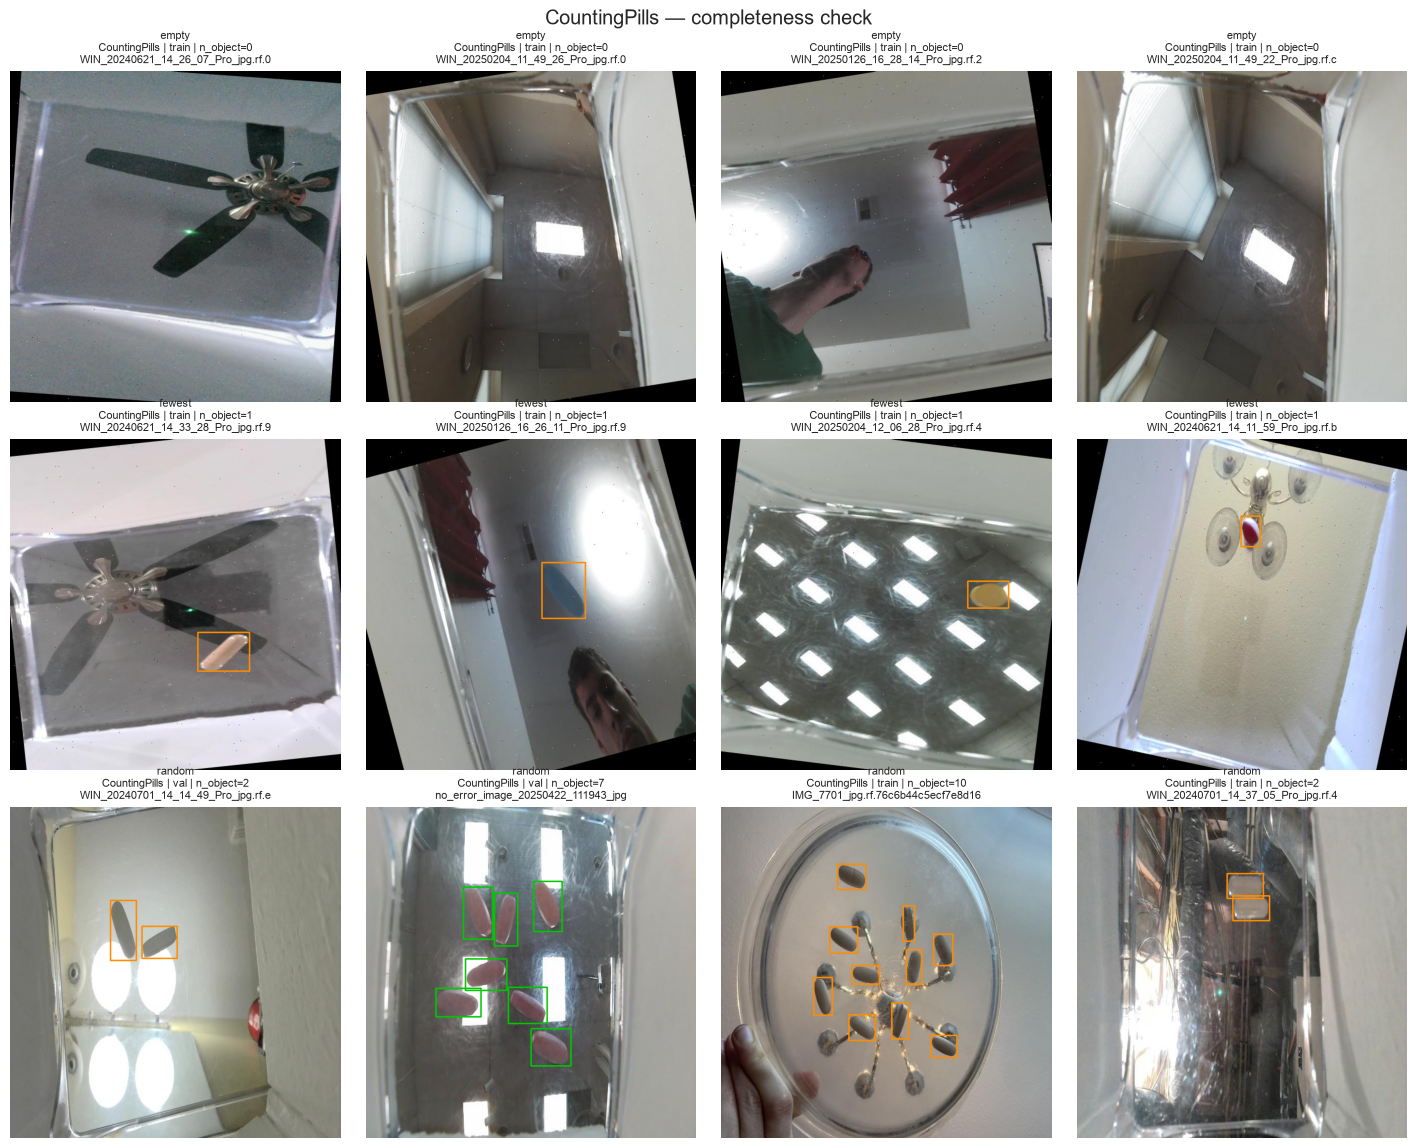

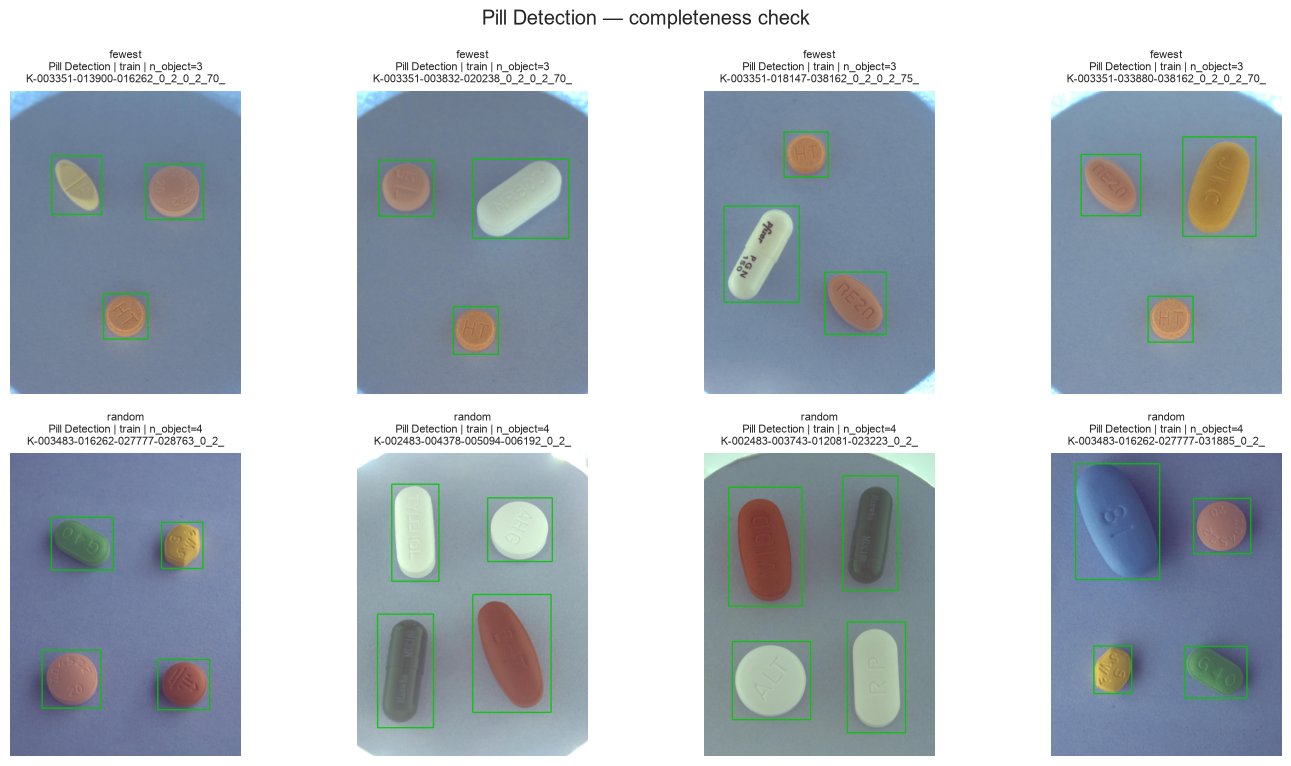

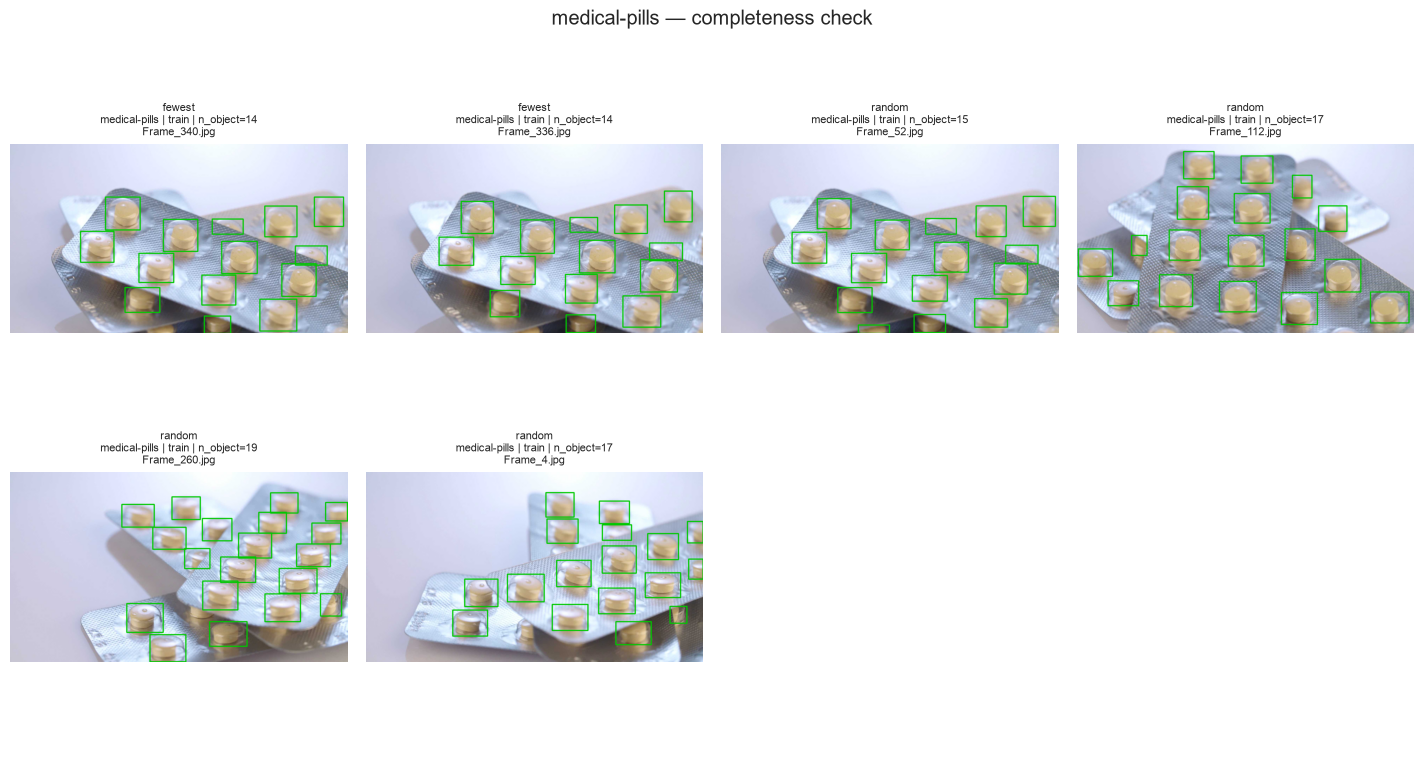

In [102]:
COLORS = {"bbox": (0, 200, 0), "polygon": (255, 140, 0)}  # RGB


def draw(path, overlay=True):
    """Load an image (RGB) and optionally draw its boxes from df_ann."""
    img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    if not overlay:
        return img
    img_h, img_w = img.shape[:2]
    thickness = max(2, max(img_h, img_w) // 300)
    for a in df_ann[df_ann["path"] == path].itertuples():
        top_left = (int((a.cx - a.w / 2) * img_w), int((a.cy - a.h / 2) * img_h))
        bottom_right = (int((a.cx + a.w / 2) * img_w), int((a.cy + a.h / 2) * img_h))
        cv2.rectangle(img, top_left, bottom_right, COLORS[a.fmt], thickness)
    return img


def pick(df, kind, n=4):
    """Sample n rows of df (a df_img subset); `note` holds the sample kind."""
    if kind == "most":
        return df.nlargest(n, "n_object").assign(note=kind)
    if kind == "empty":
        df = df[df["n_object"] == 0]
    elif kind == "fewest":
        df = df[df["n_object"] > 0]
        df = df[df["n_object"] == df["n_object"].min()]
    return df.sample(min(n, len(df)), random_state=SEED).assign(note=kind)


def show_samples(rows, ncols=4, overlay=True, title=None):
    """Plot rows (a df_img subset) as a grid titled with note, dataset, split, n_object and file."""
    nrows = max(1, (len(rows) + ncols - 1) // ncols)  # ceiling division
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(3.6 * ncols, 3.9 * nrows), squeeze=False
    )
    for ax in axes.flat:
        ax.axis("off")
    for ax, r in zip(
        axes.flat, rows.itertuples(), strict=False
    ):  # grid may have spare cells
        ax.imshow(draw(r.path, overlay))
        note = f"{r.note}\n" if "note" in rows else ""
        ax.set_title(
            f"{note}{r.dataset} | {r.split} | n_object={r.n_object}\n{r.file[:34]}",
            fontsize=8,
        )
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    return fig


for ds, d in df_img.groupby("dataset"):
    rows = pd.concat([pick(d, "empty"), pick(d, "fewest"), pick(d, "random")])
    fig = show_samples(rows, title=f"{ds} — completeness check")
    fig.savefig(FIG_DIR / f"completeness_{ds}.png", dpi=120, bbox_inches="tight")
    plt.show()

Visual inspection result — **filled in manually** from the grids above:

* **Complete**: every pill is labeled.
* **Incomplete**: some pills are unlabeled.
* **Valid Negative**: empty label and no pill in the image.

In [103]:
# Filled in manually after inspecting the grids above
completeness = pd.DataFrame(
    [
        {
            "Dataset": "CountingPills",
            "Samples Checked": 12,
            "Complete": 8,
            "Incomplete": 0,
            "Valid Negative": 4,
            "Conclusion": "Complete; empty labels are background without pills (valid negatives)",
        },
        {
            "Dataset": "Pill Detection",
            "Samples Checked": 8,
            "Complete": 8,
            "Incomplete": 0,
            "Valid Negative": 0,
            "Conclusion": "Complete; 3–4 pills per image, all labeled",
        },
        {
            "Dataset": "medical-pills",
            "Samples Checked": 6,
            "Complete": 6,
            "Incomplete": 0,
            "Valid Negative": 0,
            "Conclusion": "Complete; pills cut off at the image border are labeled",
        },
    ]
).set_index("Dataset")
display(completeness)

,Samples Checked,Complete,Incomplete,Valid Negative,Conclusion
Dataset,,,,,
CountingPills,12,8,0,4,Complete; empty labels are background without pills (valid negatives)
Pill Detection,8,8,0,0,"Complete; 3–4 pills per image, all labeled"
medical-pills,6,6,0,0,Complete; pills cut off at the image border are labeled


---
## 5. Image Properties

### 5.1 Image Statistics

Width and height come from `size`.

In [104]:
# Split size into width & height (this section only)
props = df_img[["dataset", "split", "ext"]].copy()
props["width"] = df_img["size"].str[0]
props["height"] = df_img["size"].str[1]
props["aspect"] = props["width"] / props["height"]

image_stats = props.groupby(keys, observed=True).agg(
    Images=("width", "size"),
    Width_Min=("width", "min"),
    Width_Max=("width", "max"),
    Height_Min=("height", "min"),
    Height_Max=("height", "max"),
    Aspect=("aspect", "mean"),
    Formats=("ext", join_unique),
)
image_stats.columns = [
    "Images",
    "Width Min",
    "Width Max",
    "Height Min",
    "Height Max",
    "Aspect Ratio",
    "Formats",
]
display(image_stats.round(3))

Images  Width Min  Width Max  Height Min  Height Max  \
dataset        split                                                         
CountingPills  train    6450        640        640         640         640   
               val       386        640        640         640         640   
               test      175        640        640         640         640   
Pill Detection train    1489        976        976        1280        1280   
medical-pills  train      92       1920       1920        1080        1080   
               val        23       1920       1920        1080        1080   

                      Aspect Ratio Formats  
dataset        split                        
CountingPills  train         1.000    .jpg  
               val           1.000    .jpg  
               test          1.000    .jpg  
Pill Detection train         0.762    .jpg  
medical-pills  train         1.778    .jpg  
               val           1.778    .jpg

Notes:

* **CountingPills** is 640×640 everywhere due to Roboflow *Resize to 640x640 (Stretch)* → object aspect ratios are distorted (Section 8 values are post-distortion).
* **Pill Detection** (976×1280, portrait) and **medical-pills** (1920×1080, landscape) have a constant size per dataset; they are letterboxed to 640 during training.

### 5.2 Resolution Distribution

Skipped when image sizes are constant per dataset.

In [105]:
n_sizes = props.groupby("dataset")[["width", "height"]].nunique()
if (n_sizes == 1).all().all():
    print("Image size is constant per dataset → no resolution plot needed.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, col in zip(axes, ["width", "height", "aspect"], strict=True):
        sns.histplot(data=props, x=col, hue="dataset", element="step", ax=ax)
    fig.savefig(FIG_DIR / "image_resolution.png", dpi=150, bbox_inches="tight")
    plt.show()

Image size is constant per dataset → no resolution plot needed.


---
## 6. Class Mapping

### 6.1 Class Mapping

All original classes map to `pill`. The 74 Pill Detection classes only show **pill-type diversity**; they are not training targets.

,Orig. Classes,Objects,Objects/Class Min,Objects/Class Median,Objects/Class Max,Unified Class
dataset,,,,,,
CountingPills,1,25635,25635,25635.0,25635,pill
Pill Detection,74,5662,6,45.0,622,pill
medical-pills,1,2022,2022,2022.0,2022,pill


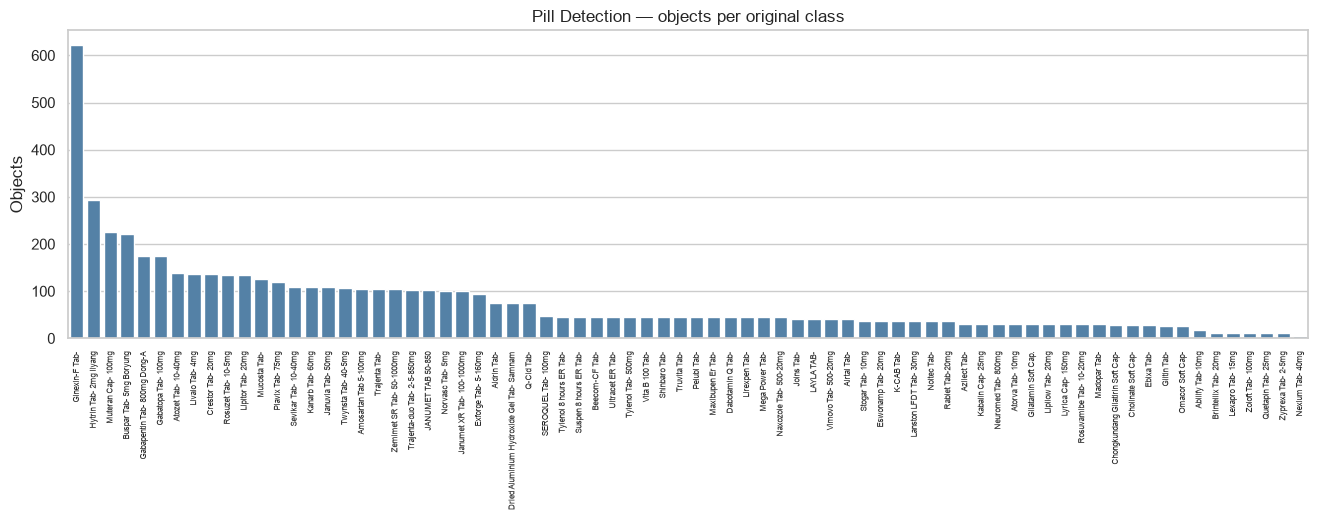

In [106]:
# Original class names per dataset (from yaml)
class_names = {}
for folder, ds in DATASETS.items():
    names = dataset_yaml(RAW_DIR / folder)["names"]
    if isinstance(names, dict):  # {0: "pill"} -> ["pill"]
        names = list(names.values())
    class_names[ds] = names

class_map = (
    df_ann.groupby(["dataset", "orig_class"]).size().rename("Objects").reset_index()
)
class_map["Original Class"] = [
    class_names[ds][c]
    for ds, c in zip(class_map["dataset"], class_map["orig_class"], strict=True)
]
class_map["Unified Class"] = "pill"

class_summary = class_map.groupby("dataset").agg(
    Classes=("orig_class", "nunique"),
    Objects=("Objects", "sum"),
    Min=("Objects", "min"),
    Median=("Objects", "median"),
    Max=("Objects", "max"),
)
class_summary.columns = [
    "Orig. Classes",
    "Objects",
    "Objects/Class Min",
    "Objects/Class Median",
    "Objects/Class Max",
]
class_summary["Unified Class"] = "pill"
display(class_summary)

# Pill-type diversity in Pill Detection
pd_classes = class_map[class_map["dataset"] == "Pill Detection"].sort_values(
    "Objects", ascending=False
)
fig, ax = plt.subplots(figsize=(16, 4))
sns.barplot(data=pd_classes, x="Original Class", y="Objects", color="steelblue", ax=ax)
ax.set(title="Pill Detection — objects per original class", xlabel="")
ax.tick_params(axis="x", rotation=90, labelsize=6)
fig.savefig(FIG_DIR / "pill_detection_classes.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Object Density

The key section for counting. `n_object` = pills per image.

### 7.1 Density Statistics

In [107]:
def p95(values):
    return values.quantile(0.95)


dens = df_img[keys + ["n_object"]].copy()
dens["ge10"] = dens["n_object"] >= 10
dens["ge20"] = dens["n_object"] >= 20

density = dens.groupby(keys, observed=True).agg(
    Images=("n_object", "size"),
    Min=("n_object", "min"),
    Mean=("n_object", "mean"),
    Median=("n_object", "median"),
    Max=("n_object", "max"),
    Std=("n_object", "std"),
    P95=("n_object", p95),
    GE10=("ge10", "sum"),
    GE20=("ge20", "sum"),
)
density = density.rename(columns={"GE10": "≥ 10", "GE20": "≥ 20"})
display(density.round(2))

Images  Min   Mean  Median  Max   Std   P95  ≥ 10  ≥ 20
dataset        split                                                         
CountingPills  train    6450    0   3.53     3.0   39  3.42   9.0   300    36
               val       386    0   5.22     4.0   23  3.95  12.0    51     3
               test      175    0   4.81     4.0   13  3.24  11.0    18     0
Pill Detection train    1489    3   3.80     4.0    4  0.40   4.0     0     0
medical-pills  train      92   14  17.64    17.5   21  1.60  20.0    92    16
               val        23   15  17.35    17.0   20  1.56  20.0    23     3

### 7.2 Density Distribution

Which density ranges are covered, and which bins lack data?

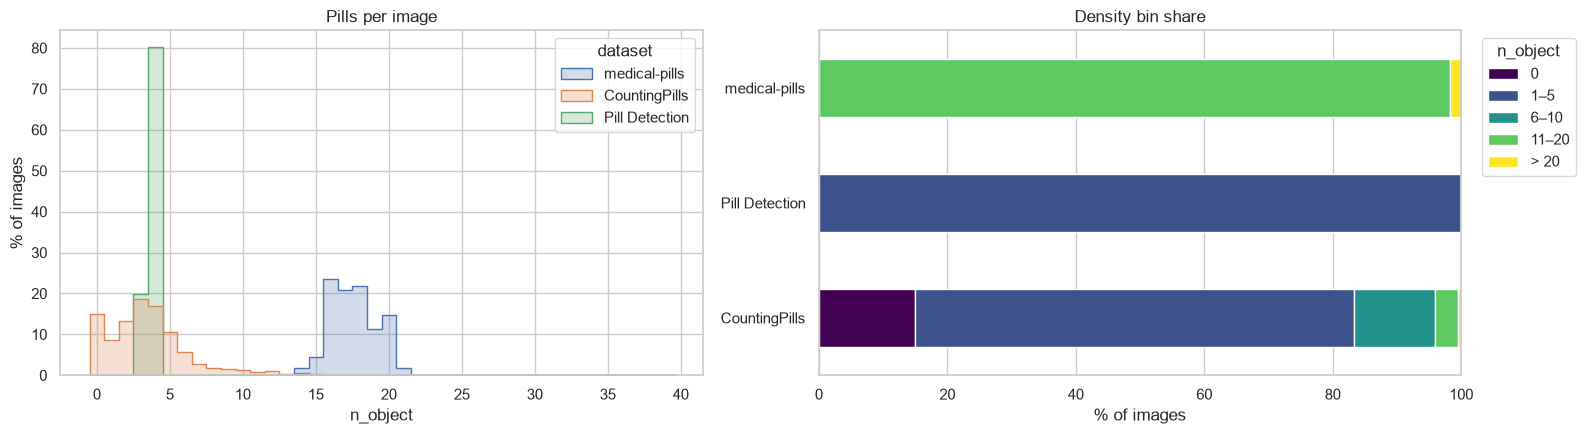

In [108]:
DENSITY_BINS = [-1, 0, 5, 10, 20, np.inf]
DENSITY_LABELS = ["0", "1–5", "6–10", "11–20", "> 20"]
density_bin = pd.cut(
    df_img["n_object"], DENSITY_BINS, labels=DENSITY_LABELS
)  # reused in 13.3

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
sns.histplot(
    data=df_img,
    x="n_object",
    hue="dataset",
    discrete=True,
    stat="percent",
    common_norm=False,
    element="step",
    ax=axes[0],
)
axes[0].set(title="Pills per image", xlabel="n_object", ylabel="% of images")

bin_share = pd.crosstab(df_img["dataset"], density_bin, normalize="index") * 100
bin_share.plot.barh(stacked=True, colormap="viridis", ax=axes[1])
axes[1].set(title="Density bin share", xlabel="% of images", ylabel="")
axes[1].legend(title="n_object", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
fig.savefig(FIG_DIR / "density_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 8. Object Geometry

### 8.1 Bounding Box Statistics

Pixel sizes are computed at `IMGSZ = 640` (letterbox: longest side → 640), as seen by the model. Small/Tiny follow the COCO area definitions (< 32² and < 16² px).

Example: a 4000 × 3000 image → `scale` = 640 / 4000 = 0.16; a pill with normalized width 0.05 → 0.05 × 4000 × 0.16 = **32 px**.

In [109]:
# Object size in pixels @IMGSZ (reused in 10.2, 12.2, 13.3)
geo = df_ann.merge(df_img[["path", "size"]], on="path")
img_w = geo["size"].str[0]
img_h = geo["size"].str[1]
scale = IMGSZ / np.maximum(img_w, img_h)

geo["w_px"] = geo["w"] * img_w * scale
geo["h_px"] = geo["h"] * img_h * scale
geo["area_px"] = geo["w_px"] * geo["h_px"]
geo["size_px"] = np.sqrt(geo["area_px"])  # side length if the object were square
geo["area_rel"] = geo["w"] * geo["h"]  # object area / image area
geo["aspect"] = geo["w_px"] / geo["h_px"]  # > 1 = wide, < 1 = tall
geo["small"] = geo["area_px"] < 32**2
geo["tiny"] = geo["area_px"] < 16**2

geometry = geo.groupby(keys, observed=True).agg(
    Width=("w_px", "mean"),
    Height=("h_px", "mean"),
    Area=("area_rel", "mean"),
    Aspect=("aspect", "mean"),
    Small=("small", "mean"),
    Tiny=("tiny", "mean"),
)
geometry[["Small", "Tiny"]] *= 100  # ratio -> percent
geometry.columns = [
    "Width Mean (px)",
    "Height Mean (px)",
    "Rel. Area Mean",
    "Aspect Ratio Mean",
    "Small < 32 px (%)",
    "Tiny < 16 px (%)",
]
display(geometry.round(3))

Width Mean (px)  Height Mean (px)  Rel. Area Mean  \
dataset        split                                                      
CountingPills  train           63.698            65.667           0.010   
               val             55.818            73.312           0.010   
               test            60.121            82.889           0.012   
Pill Detection train          128.708           144.313           0.062   
medical-pills  train           60.112            49.685           0.013   
               val             60.219            49.915           0.013   

                      Aspect Ratio Mean  Small < 32 px (%)  Tiny < 16 px (%)  
dataset        split                                                          
CountingPills  train              1.134              0.887             0.000  
               val                0.891              0.596             0.000  
               test               0.794              0.000             0.000  
Pill Detection train              0.979              0.000             0.000  
medical-pills  train              1.260              2.157             0.000  
               val                1.268              1.754             0.251

### 8.2 Geometry Distribution

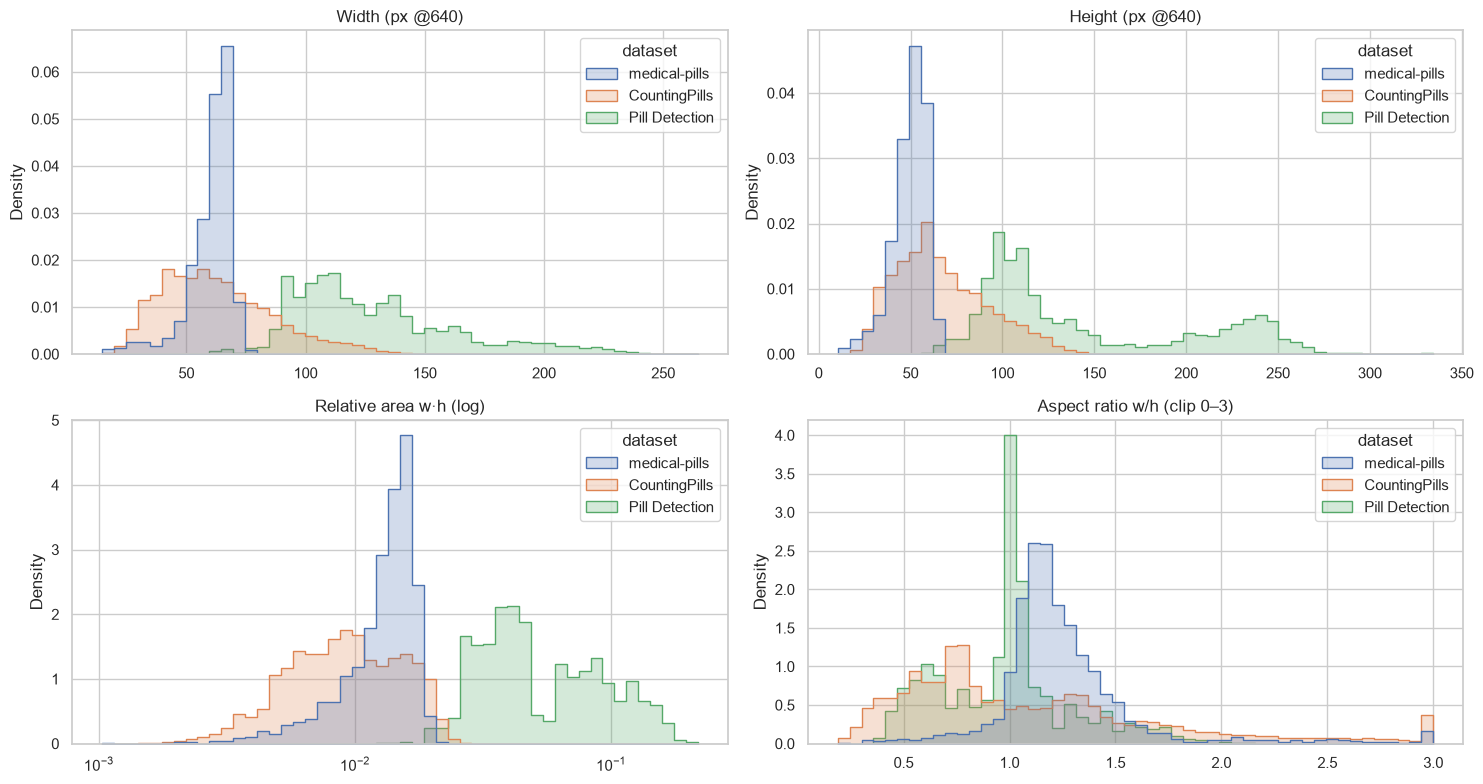

In [110]:
panels = [
    ("w_px", "Width (px @640)", False),
    ("h_px", "Height (px @640)", False),
    ("area_rel", "Relative area w·h (log)", True),
    ("aspect", "Aspect ratio w/h (clip 0–3)", False),
]
data = geo.assign(aspect=geo["aspect"].clip(0, 3))  # clip the long tail for readability

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax, (col, title, log) in zip(axes.flat, panels, strict=True):
    sns.histplot(
        data=data,
        x=col,
        hue="dataset",
        stat="density",
        common_norm=False,
        element="step",
        log_scale=log,
        bins=50,
        ax=ax,
    )
    ax.set(title=title, xlabel="")
fig.tight_layout()
fig.savefig(FIG_DIR / "object_geometry.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.3 Object Overlap

Touching or stacked pills are hard cases for counting. Based on `n_overlap` (intersecting box pairs per image).

In [111]:
ov = df_img[["dataset", "n_overlap"]].copy()
ov["has_overlap"] = ov["n_overlap"] > 0

overlap = ov.groupby("dataset").agg(
    Images=("n_overlap", "size"),
    With=("has_overlap", "sum"),
    Pct=("has_overlap", "mean"),
    Pairs=("n_overlap", "sum"),
    Max=("n_overlap", "max"),
)
overlap["Pct"] *= 100
overlap.columns = [
    "Images",
    "Images with Overlap",
    "Overlap Images (%)",
    "Overlapping Pairs",
    "Max Pairs/Image",
]
display(overlap.round(2))

,Images,Images with Overlap,Overlap Images (%),Overlapping Pairs,Max Pairs/Image
dataset,,,,,
CountingPills,7011,3554,50.69,12280,79
Pill Detection,1489,2,0.13,2,1
medical-pills,115,59,51.30,140,9


---
## 9. Spatial Distribution

### 9.1 Object Position

Are objects spread evenly, or is there a spatial bias?

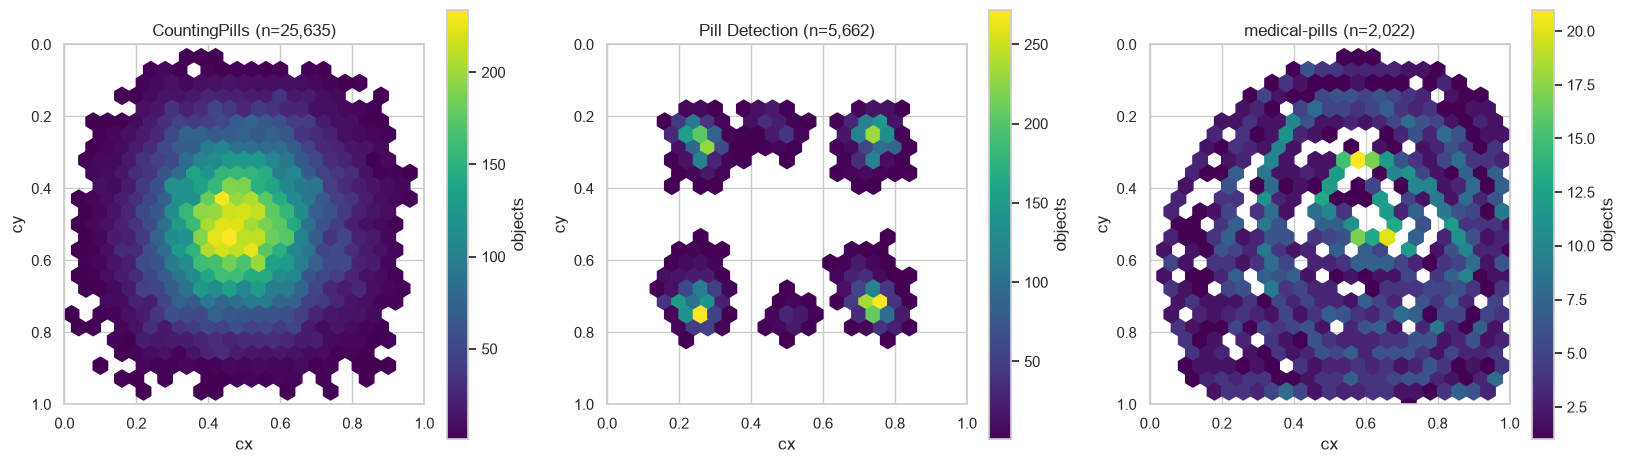

In [112]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(5.5 * len(DATASETS), 4.8))
for ax, (ds, d) in zip(axes, df_ann.groupby("dataset"), strict=True):
    hb = ax.hexbin(
        d["cx"], d["cy"], gridsize=25, extent=(0, 1, 0, 1), cmap="viridis", mincnt=1
    )
    ax.set(
        title=f"{ds} (n={len(d):,})",
        xlim=(0, 1),
        ylim=(1, 0),
        aspect="equal",
        xlabel="cx",
        ylabel="cy",
    )
    fig.colorbar(hb, ax=ax, label="objects")
fig.tight_layout()
fig.savefig(FIG_DIR / "spatial_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 10. Visual Inspection

### 10.1 Random Samples (no overlay)

Real image conditions: background, lighting, pill types.

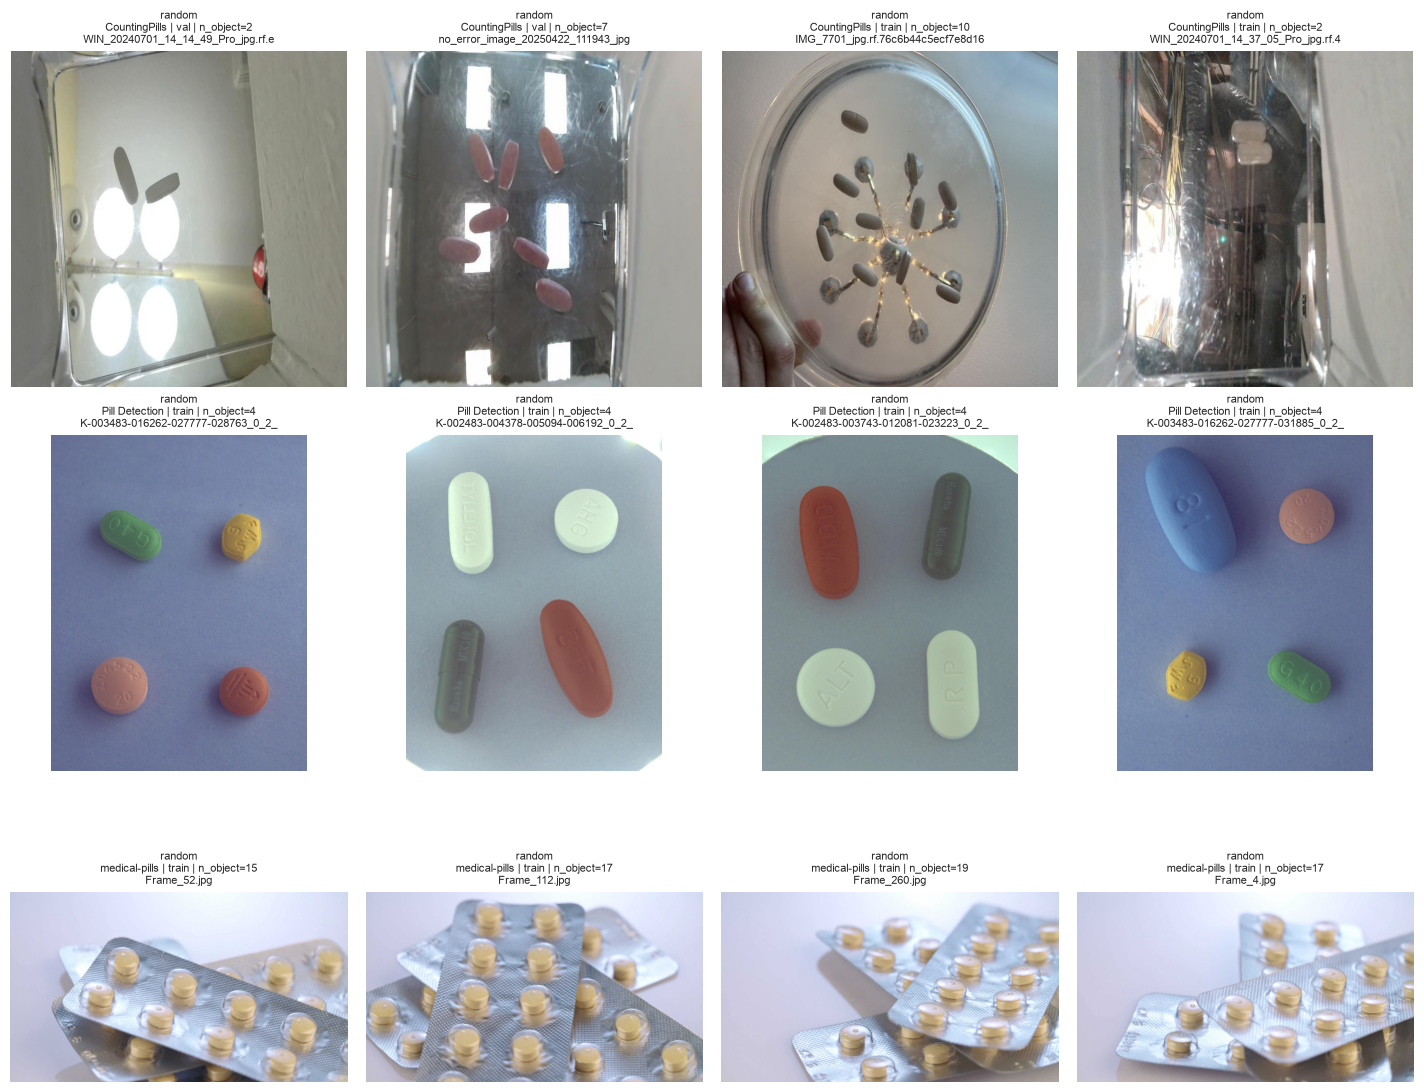

In [113]:
rows = pd.concat([pick(d, "random") for _, d in df_img.groupby("dataset")])
fig = show_samples(rows, overlay=False)
fig.savefig(FIG_DIR / "random_samples.png", dpi=120, bbox_inches="tight")
plt.show()

### 10.2 Annotation Overlay & Extreme Samples

Per dataset: random, fewest/most objects, smallest/largest object and most overlap — to confirm extremes are valid, not annotation errors.

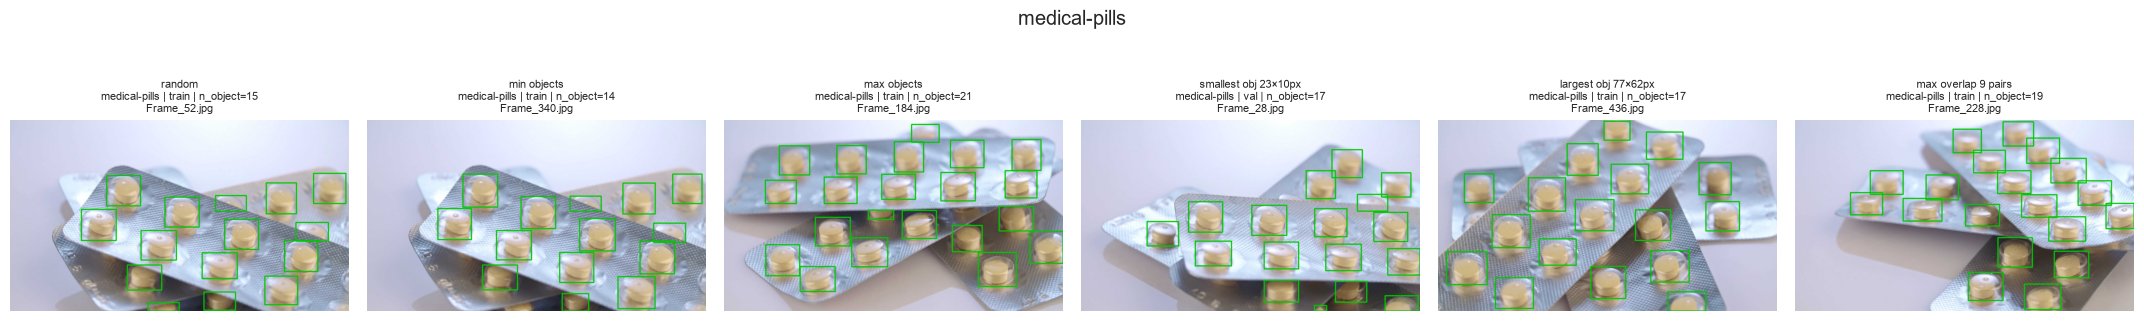

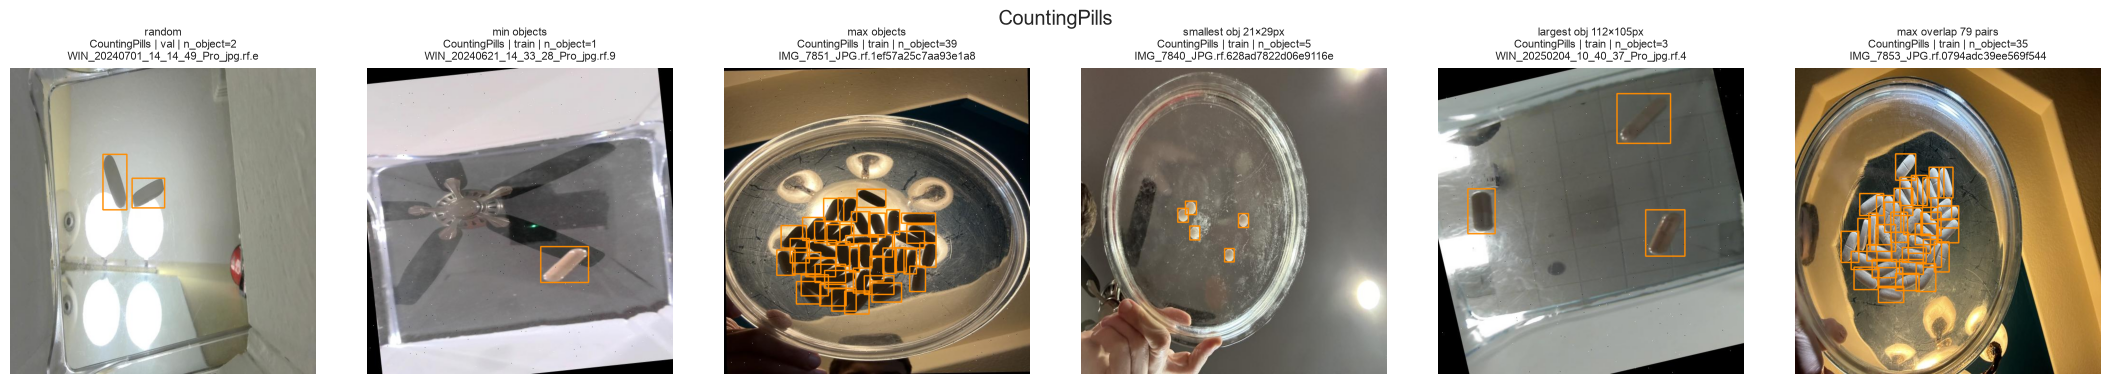

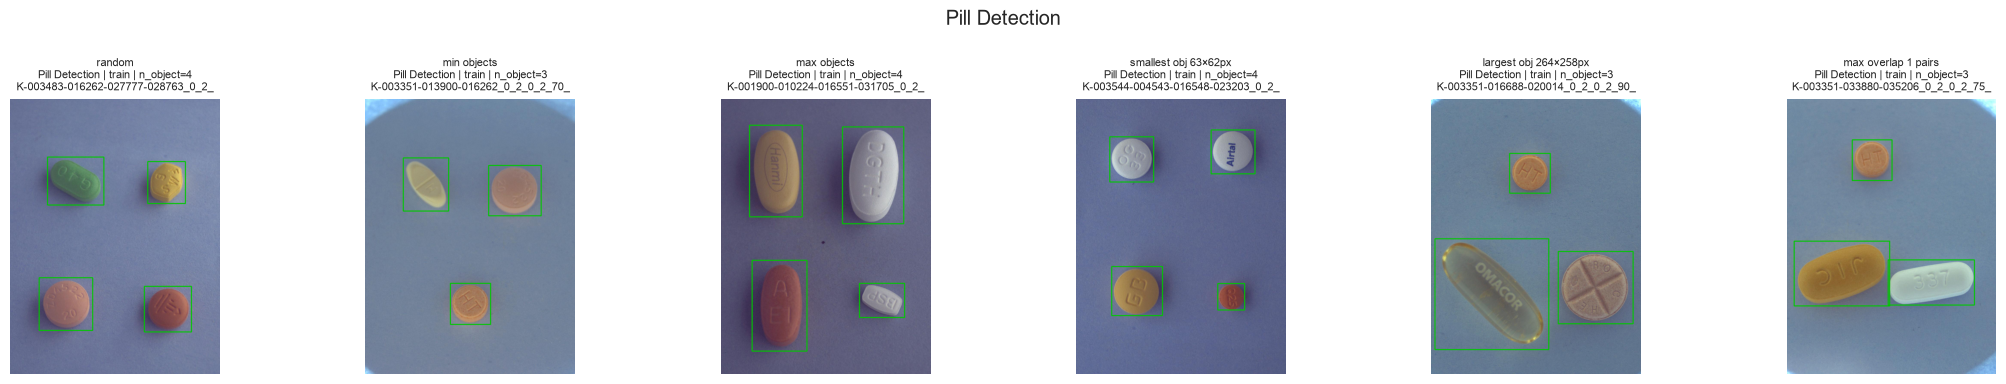

In [114]:
def extremes(ds):
    d = df_img[df_img["dataset"] == ds]
    g = geo[geo["dataset"] == ds]
    smallest = g.loc[g["area_px"].idxmin()]
    largest = g.loc[g["area_px"].idxmax()]
    return pd.concat(
        [
            pick(d, "random", 1),
            pick(d, "fewest", 1).assign(note="min objects"),
            pick(d, "most", 1).assign(note="max objects"),
            d[d["path"] == smallest["path"]].assign(
                note=f"smallest obj {smallest['w_px']:.0f}×{smallest['h_px']:.0f}px"
            ),
            d[d["path"] == largest["path"]].assign(
                note=f"largest obj {largest['w_px']:.0f}×{largest['h_px']:.0f}px"
            ),
            d.nlargest(1, "n_overlap").assign(
                note=f"max overlap {d['n_overlap'].max()} pairs"
            ),
        ]
    )


for ds in DATASETS.values():
    fig = show_samples(extremes(ds), ncols=6, title=ds)
    fig.savefig(FIG_DIR / f"extremes_{ds}.png", dpi=120, bbox_inches="tight")
    plt.show()

---
## 11. Duplicate & Data Leakage Audit

### 11.1 Duplicate Detection

| Level | Method | Catches |
| ----- | ------ | ------- |
| Exact | `md5` | Identical files |
| Near | `dhash` (Hamming ≤ `NEAR_DUP_BITS`) **and** same box layout in `df_ann` (IoU ≥ `LAYOUT_IOU`) | Adjacent video frames, near-identical re-shots |

A hash alone is not enough: pills cover a small part of the image, so different photos with the same container background look alike. dHash candidates are therefore also checked for the same box layout.

Values = number of images involved. *Within split* = redundancy; otherwise = **leakage**. Pairs are saved to `outputs/eda/duplicate_pairs.csv` for preprocessing.

In [115]:
def pairs_with_same(col):
    """All image index pairs (i, j) with the same `col` value."""
    pairs = []
    for idx in df_img.groupby(col).groups.values():
        pairs += list(combinations(idx, 2))
    return pairs


# Boxes per image: path -> list of (cx, cy, w, h)
boxes_of = {}
for path, g in df_ann.groupby("path"):
    boxes_of[path] = list(g[["cx", "cy", "w", "h"]].itertuples(index=False))


def same_layout(path_a, path_b):
    """True if both images have the same box count and every box has a match (IoU >= LAYOUT_IOU) in the other."""
    boxes_a = boxes_of.get(path_a, [])
    boxes_b = boxes_of.get(path_b, [])
    if len(boxes_a) != len(boxes_b):
        return False
    a_matched = all(max(iou(a, b) for b in boxes_b) >= LAYOUT_IOU for a in boxes_a)
    b_matched = all(max(iou(a, b) for a in boxes_a) >= LAYOUT_IOU for b in boxes_b)
    return a_matched and b_matched


exact = pairs_with_same("md5")

# Near-duplicates: (1) dHash distance <= NEAR_DUP_BITS, (2) same box layout.
# Distances are computed in blocks of 400 images to limit memory.
paths = df_img["path"].to_numpy()
hashes = np.stack(
    [np.frombuffer(bytes.fromhex(h), dtype=np.uint64) for h in df_img["dhash"]]
)
near = []
for start in range(0, len(hashes), 400):
    block = hashes[start : start + 400]
    dist = np.bitwise_count(block[:, None] ^ hashes[None]).sum(
        -1
    )  # (block, all images)
    for i, j in zip(*np.nonzero(dist <= NEAR_DUP_BITS), strict=True):
        i = i + start
        if i < j and same_layout(paths[i], paths[j]):
            near.append((i, j))
near = sorted(set(near) - set(exact))

pairs = pd.DataFrame(
    [(i, j, "Exact") for i, j in exact] + [(i, j, "Near") for i, j in near],
    columns=["i", "j", "kind"],
)


def scope(a, b):
    if a.dataset != b.dataset:
        return " ↔ ".join(sorted([a.dataset, b.dataset])), "Cross-dataset"
    if a.split == b.split:
        return a.dataset, "Within split"
    sa, sb = sorted([a.split, b.split], key=SPLITS.index)
    return a.dataset, f"{sa} ↔ {sb}"


pairs[["dataset", "scope"]] = [
    scope(a, b)
    for a, b in zip(
        df_img.loc[pairs["i"]].itertuples(),
        df_img.loc[pairs["j"]].itertuples(),
        strict=True,
    )
]

# Both images of a pair count as involved
involved = pd.concat(
    [
        pairs[["i", "dataset", "scope", "kind"]].rename(columns={"i": "img"}),
        pairs[["j", "dataset", "scope", "kind"]].rename(columns={"j": "img"}),
    ]
)
counts = involved.groupby(["dataset", "scope", "kind"])["img"].nunique().unstack("kind")

# All checked combinations, including zero results
expected = []
for ds, d in df_img.groupby("dataset"):
    present = [s for s in SPLITS if s in set(d["split"])]
    expected += [(ds, "Within split")] + [
        (ds, f"{a} ↔ {b}") for a, b in combinations(present, 2)
    ]
expected += [
    (f"{a} ↔ {b}", "Cross-dataset")
    for a, b in combinations(sorted(DATASETS.values()), 2)
]
index = pd.MultiIndex.from_tuples(expected, names=["dataset", "scope"])

dup_audit = counts.reindex(index=index, columns=["Exact", "Near"]).fillna(0).astype(int)
dup_audit.columns = ["Exact Dup. Images", "Near-Dup. Images"]
n_imgs = df_img["dataset"].value_counts()
dup_audit.insert(
    0, "Total Images", [sum(n_imgs[x] for x in ds.split(" ↔ ")) for ds, _ in index]
)
display(dup_audit)

# Save pairs for preprocessing (paths relative to ml/, see 1.3)
duplicate_pairs = pd.DataFrame(
    {
        "path_a": df_img.loc[pairs["i"], "path"].map(rel).to_numpy(),
        "path_b": df_img.loc[pairs["j"], "path"].map(rel).to_numpy(),
        "kind": pairs["kind"],
        "dataset": pairs["dataset"],
        "scope": pairs["scope"],
    }
)
duplicate_pairs.to_csv(REPORTS_DIR / "duplicate_pairs.csv", index=False)
print(f"duplicate_pairs.csv : {len(duplicate_pairs):,} pairs")

Total Images  Exact Dup. Images  \
dataset                        scope                                            
CountingPills                  Within split           7011                  0   
                               train ↔ val            7011                  0   
                               train ↔ test           7011                  0   
                               val ↔ test             7011                  0   
Pill Detection                 Within split           1489                  0   
medical-pills                  Within split            115                  0   
                               train ↔ val             115                  0   
CountingPills ↔ Pill Detection Cross-dataset          8500                  0   
CountingPills ↔ medical-pills  Cross-dataset          7126                  0   
Pill Detection ↔ medical-pills Cross-dataset          1604                  0   

                                              Near-Dup. Images  
dataset                        scope                            
CountingPills                  Within split                195  
                               train ↔ val                  10  
                               train ↔ test                 12  
                               val ↔ test                    0  
Pill Detection                 Within split                299  
medical-pills                  Within split                 14  
                               train ↔ val                   6  
CountingPills ↔ Pill Detection Cross-dataset                 0  
CountingPills ↔ medical-pills  Cross-dataset                 0  
Pill Detection ↔ medical-pills Cross-dataset                 0

duplicate_pairs.csv : 428 pairs


Visual check of near-duplicates (consecutive pairs, `d` = dHash Hamming distance):

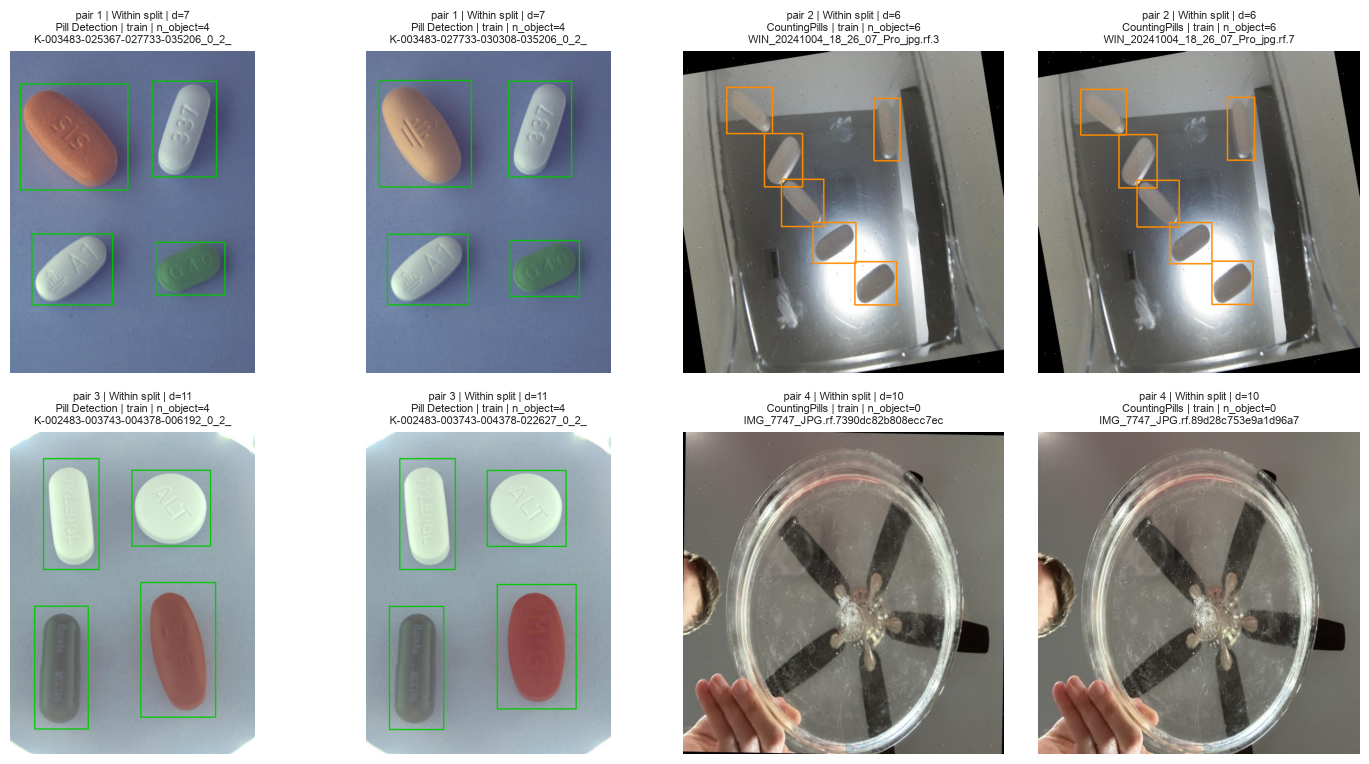

In [116]:
near_pairs = pairs[pairs["kind"] == "Near"]
sample = near_pairs.sample(min(4, len(near_pairs)), random_state=SEED)

rows = []
for k, (i, j, sc) in enumerate(
    zip(sample["i"], sample["j"], sample["scope"], strict=True), start=1
):
    d = int(np.bitwise_count(hashes[i] ^ hashes[j]).sum())
    rows.append(df_img.loc[[i, j]].assign(note=f"pair {k} | {sc} | d={d}"))

fig = show_samples(pd.concat(rows))
fig.savefig(FIG_DIR / "near_duplicates.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 12. Split Analysis

### 12.1 Split Distribution

In [117]:
split_dist = pd.crosstab(df_img["dataset"], df_img["split"]).reindex(
    columns=SPLITS, fill_value=0
)
split_dist.columns = ["Train", "Val", "Test"]
split_dist["Total"] = split_dist.sum(axis=1)
for c in ["Train", "Val", "Test"]:
    split_dist[f"{c} %"] = (100 * split_dist[c] / split_dist["Total"]).round(1)

missing = []
for _, r in split_dist.iterrows():
    names = [c for c in ["Train", "Val", "Test"] if r[c] == 0]
    missing.append(", ".join(names) if names else "-")
split_dist["Missing Splits"] = missing
display(split_dist)

,Train,Val,Test,Total,Train %,Val %,Test %,Missing Splits
dataset,,,,,,,,
CountingPills,6450,386,175,7011,92.0,5.5,2.5,-
Pill Detection,1489,0,0,1489,100.0,0.0,0.0,"Val, Test"
medical-pills,92,23,0,115,80.0,20.0,0.0,Test


### 12.2 Split Consistency

For datasets with more than one split: are the train/val/test distributions consistent?

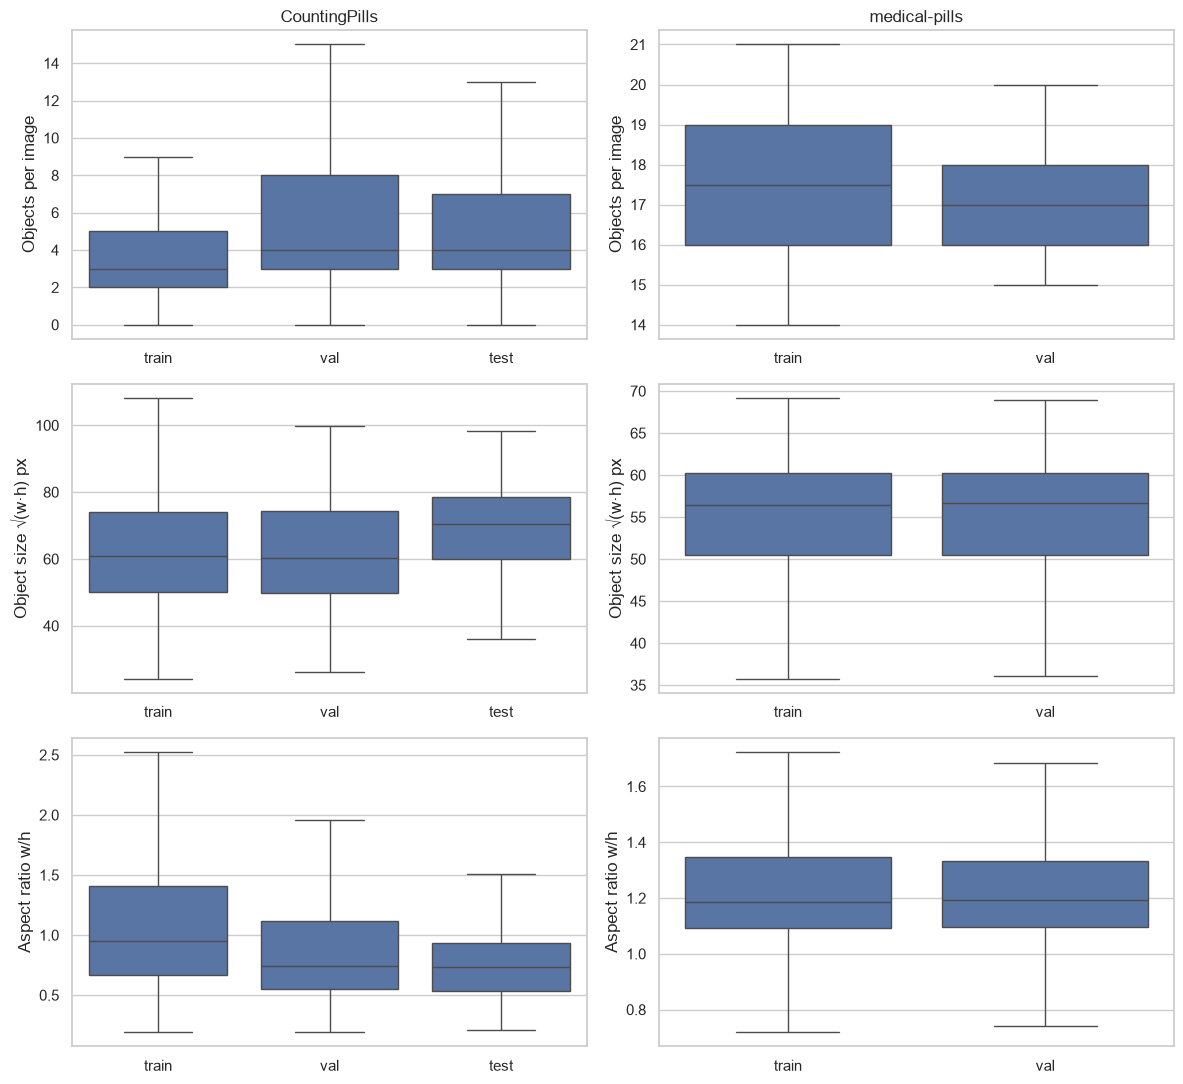

In [118]:
multi = [ds for ds, d in df_img.groupby("dataset") if d["split"].nunique() > 1]
metrics = [
    (df_img, "n_object", "Objects per image"),
    (geo, "size_px", "Object size √(w·h) px"),
    (geo, "aspect", "Aspect ratio w/h"),
]
fig, axes = plt.subplots(
    len(metrics), len(multi), figsize=(6 * len(multi), 11), squeeze=False
)
for c, ds in enumerate(multi):
    order = [
        s for s in SPLITS if s in set(df_img.loc[df_img["dataset"] == ds, "split"])
    ]
    for r, (data, col, label) in enumerate(metrics):
        d = data[data["dataset"] == ds].astype({"split": str})
        sns.boxplot(
            data=d, x="split", y=col, order=order, showfliers=False, ax=axes[r, c]
        )
        axes[r, c].set(title=ds if r == 0 else "", ylabel=label, xlabel="")
fig.tight_layout()
fig.savefig(FIG_DIR / "split_consistency.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 13. Combined Dataset Simulation

Simulates merging the datasets on the fly from `df_img` / `df_ann` (no file copies).

### 13.1 Combined Statistics

Counts for every dataset combination (1, 2 and 3 datasets).

In [119]:
combined = []
names = sorted(DATASETS.values())
for k in range(1, len(names) + 1):
    for combo in combinations(names, k):
        d = df_img[df_img["dataset"].isin(combo)]
        share = d["dataset"].value_counts(normalize=True)
        combined.append(
            {
                "Combination": " + ".join(combo),
                "Images": len(d),
                "Objects": d["n_object"].sum(),
                "Mean Objects/Image": d["n_object"].mean(),
                "Empty Images (%)": 100 * (d["n_object"] == 0).mean(),
                "Share per Dataset": " / ".join(f"{share[s]:.0%}" for s in combo),
            }
        )
combined = pd.DataFrame(combined).set_index("Combination")
display(combined.round(2))

,Images,Objects,Mean Objects/Image,Empty Images (%),Share per Dataset
Combination,,,,,
CountingPills,7011,25635,3.66,14.96,100%
Pill Detection,1489,5662,3.80,0.00,100%
medical-pills,115,2022,17.58,0.00,100%
CountingPills + Pill Detection,8500,31297,3.68,12.34,82% / 18%
CountingPills + medical-pills,7126,27657,3.88,14.72,98% / 2%
Pill Detection + medical-pills,1604,7684,4.79,0.00,93% / 7%
CountingPills + Pill Detection + medical-pills,8615,33319,3.87,12.18,81% / 17% / 1%


### 13.2 Combined Split Simulation

Train/val/test ratio after merging all three datasets:

| Scenario | Rule |
| -------- | ---- |
| A. Original splits | Each dataset's original split as is |
| B. Missing splits filled | Original splits kept; each missing split is filled from train at `SPLIT_RATIO` (8 : 1 : 1 → 10% of the dataset's images) |

Counts only. The actual split (grouped by source image to avoid leakage) is done in preprocessing.

In [120]:
# Scenario A: images per dataset & original split
split_a = pd.crosstab(df_img["dataset"], df_img["split"]).reindex(
    columns=SPLITS, fill_value=0
)
split_a.columns = (
    SPLITS  # plain (non-categorical) columns so percent columns can be added
)

# Scenario B: fill empty splits from train at SPLIT_RATIO
ratio = {
    s: r / sum(SPLIT_RATIO) for s, r in zip(SPLITS, SPLIT_RATIO, strict=True)
}  # train 0.8, val 0.1, test 0.1
split_b = split_a.copy()
for ds in split_b.index:
    total = split_a.loc[ds].sum()
    for s in ["val", "test"]:
        if split_a.loc[ds, s] == 0:
            n = round(total * ratio[s])
            split_b.loc[ds, s] = n
            split_b.loc[ds, "train"] -= n


def split_table(counts, scenario):
    """Add a combined row and per-split percentages."""
    t = counts.copy()
    t.loc["Combined"] = t.sum()
    total = t[SPLITS].sum(axis=1)
    for s in SPLITS:
        t[f"{s} %"] = (100 * t[s] / total).round(1)
    t.insert(0, "Scenario", scenario)
    return t


simulation = pd.concat(
    [
        split_table(split_a, "A. Original splits"),
        split_table(split_b, "B. Missing splits filled"),
    ]
)
simulation.index.name = "Dataset"
simulation.columns = ["Scenario", "Train", "Val", "Test", "Train %", "Val %", "Test %"]
display(simulation)

,Scenario,Train,Val,Test,Train %,Val %,Test %
Dataset,,,,,,,
CountingPills,A. Original splits,6450,386,175,92.0,5.5,2.5
Pill Detection,A. Original splits,1489,0,0,100.0,0.0,0.0
medical-pills,A. Original splits,92,23,0,80.0,20.0,0.0
Combined,A. Original splits,8031,409,175,93.2,4.7,2.0
CountingPills,B. Missing splits filled,6450,386,175,92.0,5.5,2.5
Pill Detection,B. Missing splits filled,1191,149,149,80.0,10.0,10.0
medical-pills,B. Missing splits filled,80,23,12,69.6,20.0,10.4
Combined,B. Missing splits filled,7721,558,336,89.6,6.5,3.9


### 13.3 Combined Distribution

Does the merged data cover the density & size ranges, or is it dominated by one dataset?

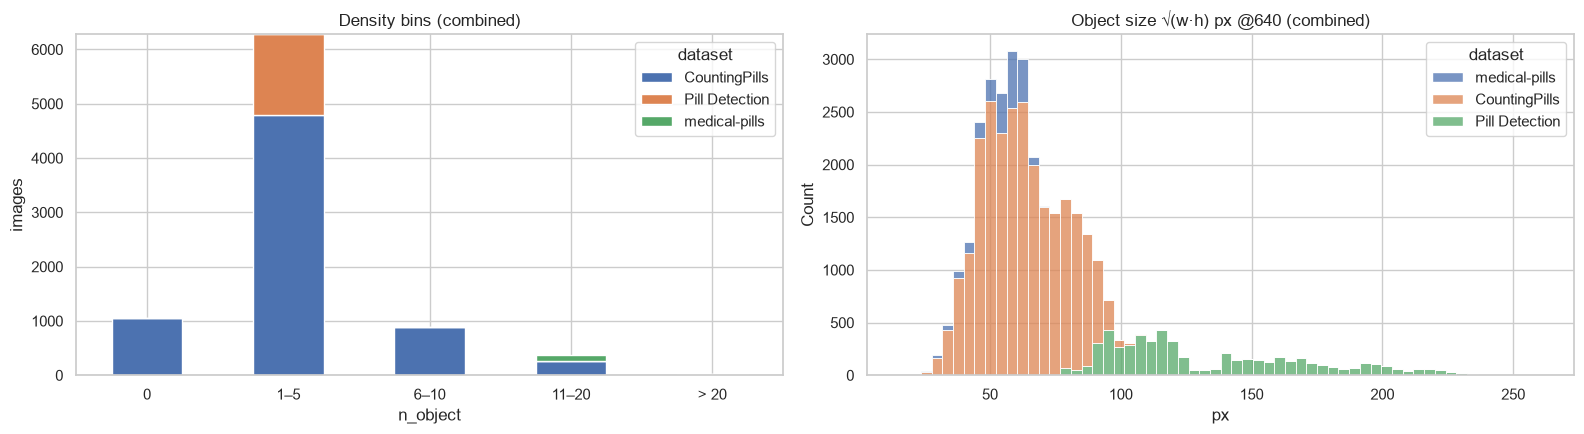

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
pd.crosstab(density_bin, df_img["dataset"]).plot.bar(stacked=True, rot=0, ax=axes[0])
axes[0].set(title="Density bins (combined)", xlabel="n_object", ylabel="images")
sns.histplot(
    data=geo, x="size_px", hue="dataset", multiple="stack", bins=60, ax=axes[1]
)
axes[1].set(title="Object size √(w·h) px @640 (combined)", xlabel="px")
fig.tight_layout()
fig.savefig(FIG_DIR / "combined_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 14. Key Findings & Decisions

### 14.1 Findings & Decisions

| # | Finding | Evidence | Decision |
| - | ------- | -------- | -------- |
| 1 | 95% of CountingPills objects are polygons; 15 files mix bbox + polygon | 3.2 | Convert all polygons to min–max bboxes |
| 2 | No missing/orphan labels, duplicate filenames or invalid rows | 3.1, 3.2 | No label cleaning |
| 3 | 1,049 CountingPills images (15%) have empty labels and are true background | 3.1, 4.1 | Keep all |
| 4 | Original classes: 1 / 74 / 1 | 6.1 | All classes → `0: pill` |
| 5 | Objects are not small: mean 50–144 px @640, small ≤ 2.2% | 8.1 | `imgsz=640` |
| 6 | Touching pills in ~51% of CountingPills & medical-pills images | 8.3 | Keep all overlapping images |
| 7 | CountingPills has 3 augmented copies per source photo (all in train), stretched to 640×640 | 2.1, 5.1 | No offline augmentation |
| 8 | Pill Detection pill positions are fixed to a few spots | 9.1 | Keep YOLO default online augmentation |
| 9 | Incomplete splits: Pill Detection is train-only, medical-pills has no test | 12.1 | Keep original splits; Pill Detection 8 : 1 : 1 by pill code; medical-pills test = 10% from train by similar-frame group |
| 10 | Pill Detection near-duplicates are mostly different pill combinations at the same positions | 11.1 | Group Pill Detection by pill code, not `duplicate_pairs.csv` |

### 14.2 Further Study

Not addressed at this stage.

| # | Item | Evidence | Suggestion |
| - | ---- | -------- | ---------- |
| 1 | Small combined val/test: 7,721 / 558 / 336 (89.6 / 6.5 / 3.9%) because CountingPills splits are kept | 13.2 | Re-split CountingPills (by source photo) if val/test metrics are unstable |
| 2 | Cross-split duplicates left as is: CountingPills 22 images, medical-pills 6 images (5%) | 11.1 | Assess their impact |
| 3 | CountingPills train differs from val/test: mean 3.5 vs 5.2 / 4.8 pills, more varied aspect ratio | 7.1, 8.1, 12.2 | Keep in mind when reading metrics |